In [2]:
!pip install seaborn

In [3]:
# installinhg xgboost and lightgbm
!pip install xgboost lightgbm


In [4]:
# installing imblearn
!pip install imbalanced-learn

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import joblib

In [6]:
df = pd.read_csv("Automobile_insurance_fraud.csv")

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## Data Understanding

In [7]:
df.shape

(1000, 40)

In [8]:
df = df.drop(columns=["policy_number", "_c39"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_bind_date             1000 non-null   object 
 3   policy_state                 1000 non-null   object 
 4   policy_csl                   1000 non-null   object 
 5   policy_deductable            1000 non-null   int64  
 6   policy_annual_premium        1000 non-null   float64
 7   umbrella_limit               1000 non-null   int64  
 8   insured_zip                  1000 non-null   int64  
 9   insured_sex                  1000 non-null   object 
 10  insured_education_level      1000 non-null   object 
 11  insured_occupation           1000 non-null   object 
 12  insured_hobbies              1000 non-null   object 
 13  insured_relationshi

In [10]:
df.dtypes

months_as_customer               int64
age                              int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of_the_day         int64
number_of_vehicles_involv

In [11]:
df.describe()

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


In [12]:
df.duplicated().sum()

0

In [13]:
df.isnull().sum()

months_as_customer              0
age                             0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses                       0
police_report_

## Exploratory Data Analysis (EDA)

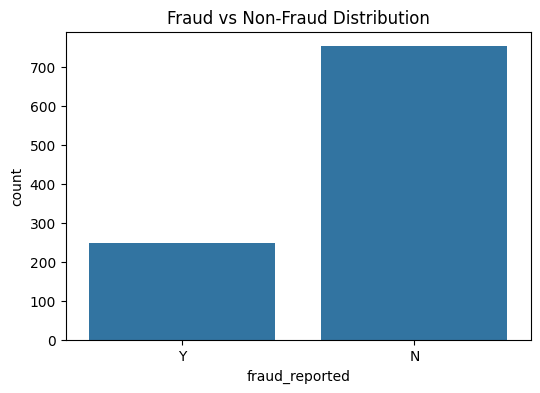

In [14]:
#Fraud Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="fraud_reported", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

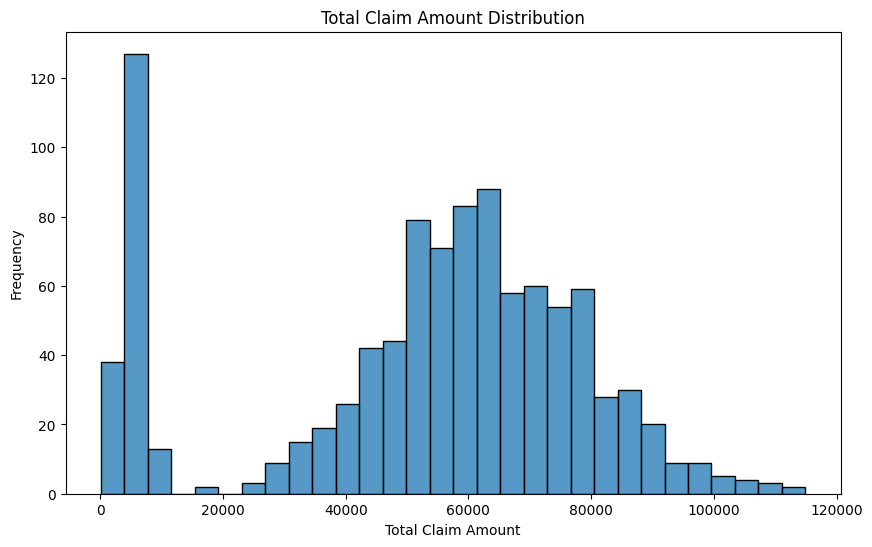

In [15]:
# Claim Amount Distribution
plt.figure(figsize=(10,6))
sns.histplot(df["total_claim_amount"], bins=30)
plt.title("Total Claim Amount Distribution")
plt.xlabel("Total Claim Amount")
plt.ylabel("Frequency")
plt.show()


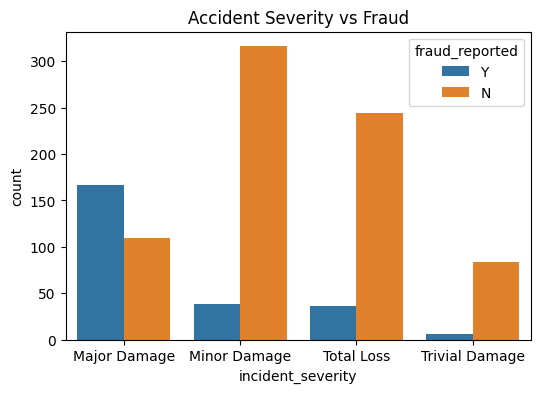

In [16]:
# Accident Severity vs Fraud
plt.figure(figsize=(6,4))
sns.countplot(
    x="incident_severity",
    hue="fraud_reported",
    data=df
)
plt.title("Accident Severity vs Fraud")
plt.show()

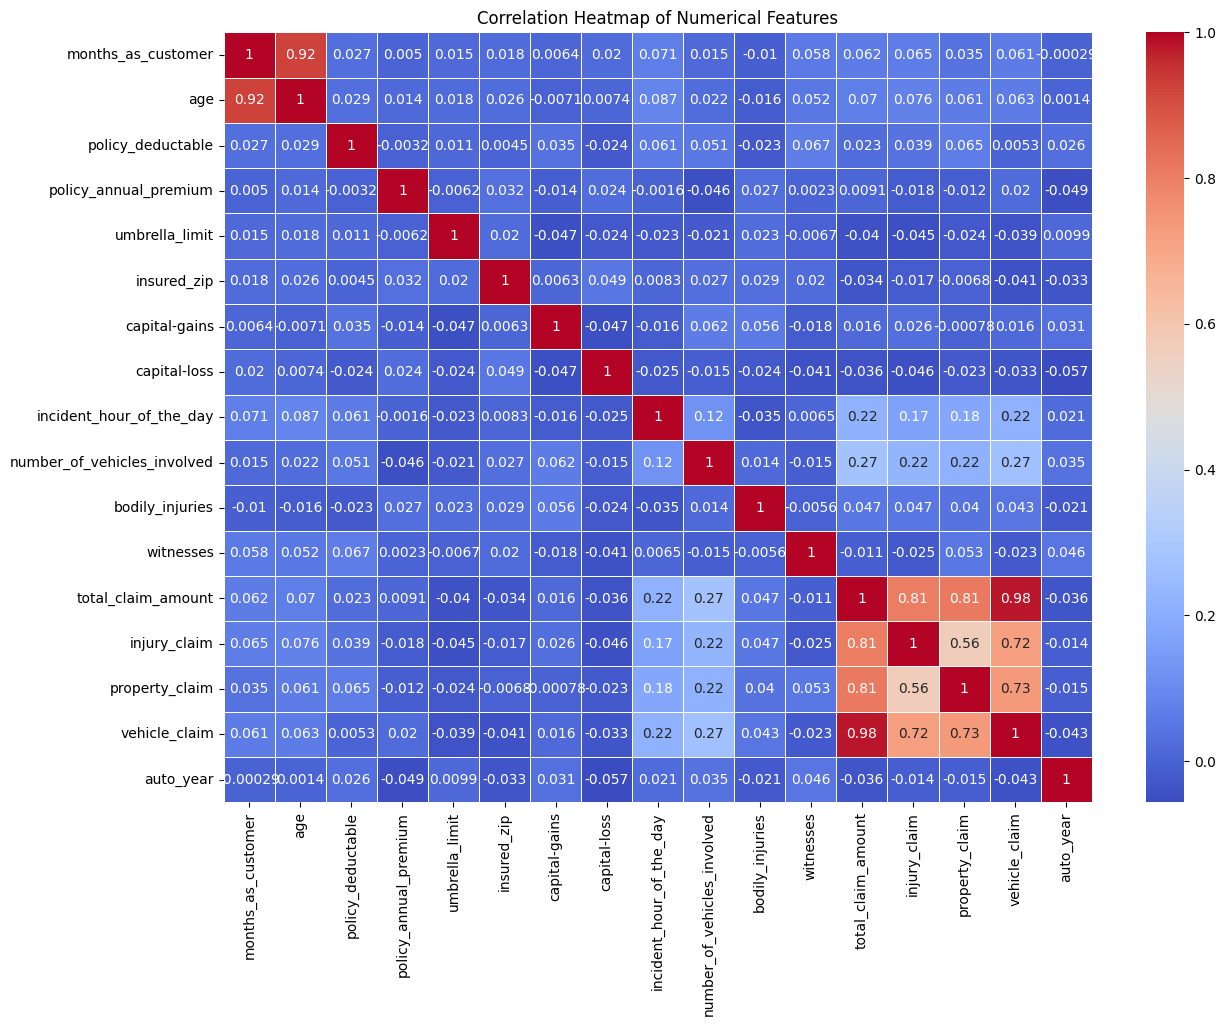

In [17]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=
0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


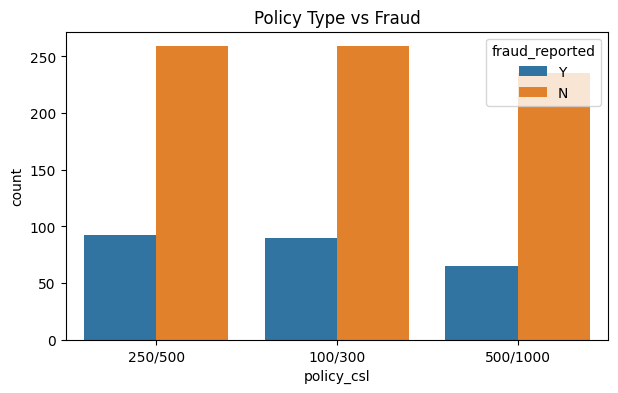

In [18]:
# Fraud Pattern Visualizations
plt.figure(figsize=(7,4))

sns.countplot(
    x="policy_csl",
    hue="fraud_reported",
    data=df
)

plt.title("Policy Type vs Fraud")

plt.show()



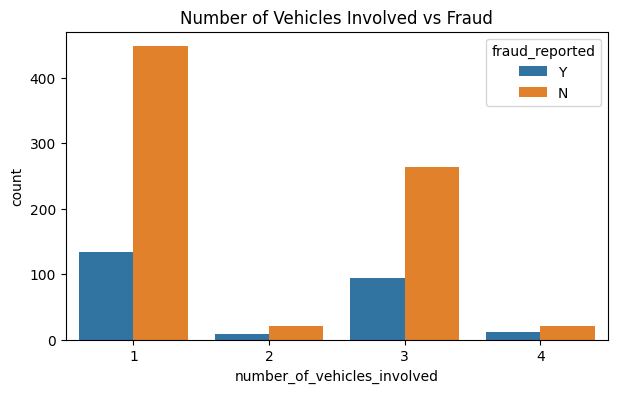

In [19]:
# Number of Vehicles vs Fraud
plt.figure(figsize=(7,4))
sns.countplot(
    x="number_of_vehicles_involved",
    hue="fraud_reported",
    data=df
)
plt.title("Number of Vehicles Involved vs Fraud")
plt.show()

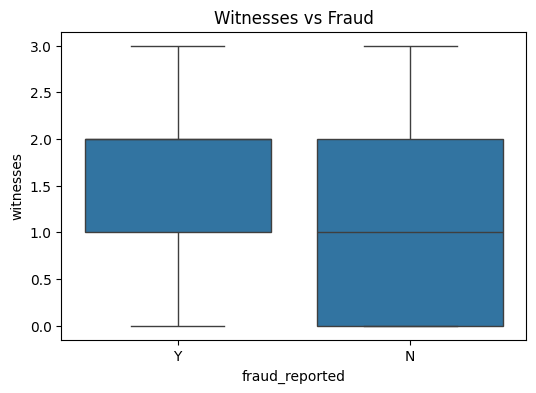

In [20]:
# Witnesses vs Fraud
plt.figure(figsize=(6,4))

sns.boxplot(
    x="fraud_reported",
    y="witnesses",
    data=df
)

plt.title("Witnesses vs Fraud")
plt.show()

## Feature Engineering

In [21]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

df["policy_year"] = df["policy_bind_date"].dt.year
df["policy_month"] = df["policy_bind_date"].dt.month

df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month

C:\Users\Tufan\AppData\Local\Temp\ipykernel_3864\3028260179.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
C:\Users\Tufan\AppData\Local\Temp\ipykernel_3864\3028260179.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["incident_date"] = pd.to_datetime(df["incident_date"])


In [22]:
df.drop(["policy_bind_date", "incident_date"], axis=1, inplace=True)

In [23]:
df.dtypes

months_as_customer               int64
age                              int64
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
property_damage                 object
bodily_injuries          

In [24]:
# Encode target variable
df["fraud_reported"] = df["fraud_reported"].map({

"Y":1,
"N":0

})

In [25]:
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

In [26]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

In [27]:
preprocessor = ColumnTransformer(

transformers=[

("num", StandardScaler(), numerical_cols),

("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)

]

)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.2,
random_state=42,
stratify=y

)

In [47]:
# Transform training data
X_train_transformed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

In [48]:
X_resampled, y_resampled = smote.fit_resample(
    X_train_transformed,
    y_train
)

In [30]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_resampled, y_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_resampled, y_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_resampled, y_resampled)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_resampled, y_resampled)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [34]:
# XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_resampled, y_resampled)

c:\Users\Tufan\anaconda3\envs\ANN_env\lib\site-packages\xgboost\training.py:200: UserWarning: [08:32:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [35]:
#LightGBM

lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_resampled, y_resampled)

[LightGBM] [Info] Number of positive: 602, number of negative: 602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7070
[LightGBM] [Info] Number of data points in the train set: 1204, number of used features: 162
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [36]:
# SVC
from sklearn.svm import SVC
svc = SVC(random_state=42)
svc.fit(X_resampled, y_resampled)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [49]:
# Convert sparse matrix to dense (ANN requires dense input)
X_resampled_dense = X_resampled.toarray()
X_test_dense = X_test_transformed.toarray()

In [50]:


ann_model = keras.Sequential([

    layers.Dense(64, activation="relu", input_shape=(X_resampled_dense.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")

])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [51]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [52]:
history = ann_model.fit(
    X_resampled_dense,
    y_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
31/31 [==============================] - 1s 8ms/step - loss: 0.7748 - accuracy: 0.5587 - val_loss: 0.6722 - val_accuracy: 0.5560
Epoch 2/50
31/31 [==============================] - 0s 3ms/step - loss: 0.5017 - accuracy: 0.7570 - val_loss: 0.6821 - val_accuracy: 0.5436
Epoch 3/50
31/31 [==============================] - 0s 3ms/step - loss: 0.3715 - accuracy: 0.8494 - val_loss: 0.6321 - val_accuracy: 0.7012
Epoch 4/50
31/31 [==============================] - 0s 3ms/step - loss: 0.2882 - accuracy: 0.9013 - val_loss: 0.5757 - val_accuracy: 0.8050
Epoch 5/50
31/31 [==============================] - 0s 3ms/step - loss: 0.2159 - accuracy: 0.9325 - val_loss: 0.5130 - val_accuracy: 0.9004
Epoch 6/50
31/31 [==============================] - 0s 3ms/step - loss: 0.1894 - accuracy: 0.9408 - val_loss: 0.4481 - val_accuracy: 0.9378
Epoch 7/50
31/31 [==============================] - 0s 3ms/step - loss: 0.1349 - accuracy: 0.9668 - val_loss: 0.3902 - val_accuracy: 0.9585
Epoch 8/50
31/31 [==

In [53]:
# ANN prediction
y_pred_ann = (ann_model.predict(X_test_dense) > 0.5).astype(int)

7/7 [==============================] - 0s 1ms/step


In [54]:
# Evaluate ANN
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       151
           1       0.58      0.45      0.51        49

    accuracy                           0.79       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.77      0.79      0.78       200



## Model Evaluation

In [ ]:
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
# evaluation using all models
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "LightGBM": lgb_model,
    "SVC": svc
}


In [ ]:
# print classification report for each model
for name, model in models.items():
    y_pred = model.predict(X_test_transformed)
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred))
    print("-" * 60)


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       151
           1       0.64      0.65      0.65        49

    accuracy                           0.82       200
   macro avg       0.76      0.77      0.77       200
weighted avg       0.83      0.82      0.83       200

------------------------------------------------------------
Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       151
           1       0.65      0.57      0.61        49

    accuracy                           0.82       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.81      0.82      0.82       200

------------------------------------------------------------
Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.80      0.94    

d:\Digital Hashtag Internship\Project 1\environment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# model comparison
model_names = list(models.keys())
model_accuracies = [classification_report(y_test, model.predict(X_test_transformed), output_dict=True)["accuracy"] for model in models.values()]
accuracy_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": model_accuracies
}).sort_values(by="Accuracy", ascending=False)
print(accuracy_df)


                 Model  Accuracy
3    Gradient Boosting     0.830
0  Logistic Regression     0.825
1        Decision Tree     0.820
5             LightGBM     0.815
4              XGBoost     0.810
6                  SVC     0.800
2        Random Forest     0.780


d:\Digital Hashtag Internship\Project 1\environment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


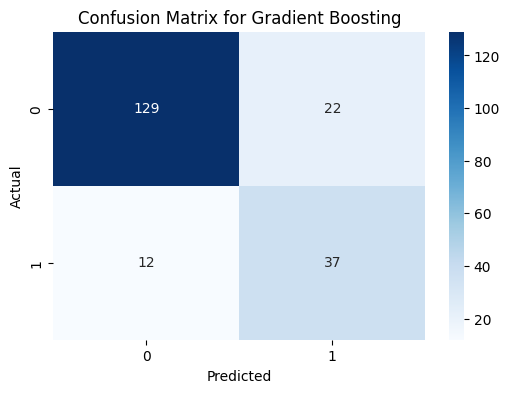

In [ ]:
# Confusion Matrix for best model Gradient Boosting 
best_model = gb
y_pred_best = best_model.predict(X_test_transformed)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Gradient Boosting")
plt.xlabel("Predicted")

plt.ylabel("Actual")
plt.show()

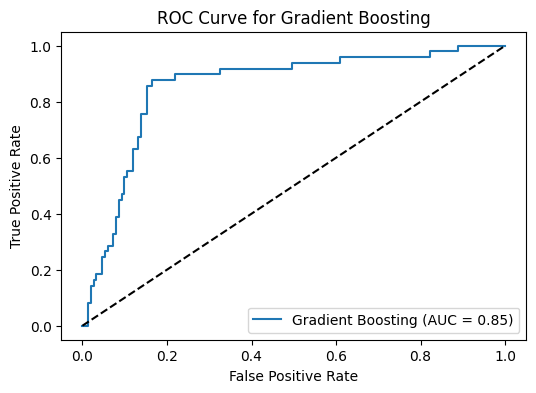

In [ ]:
# ROC Curves for best model
y_prob = best_model.predict_proba(X_test_transformed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Gradient Boosting (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Gradient Boosting")
plt.legend()
plt.show()


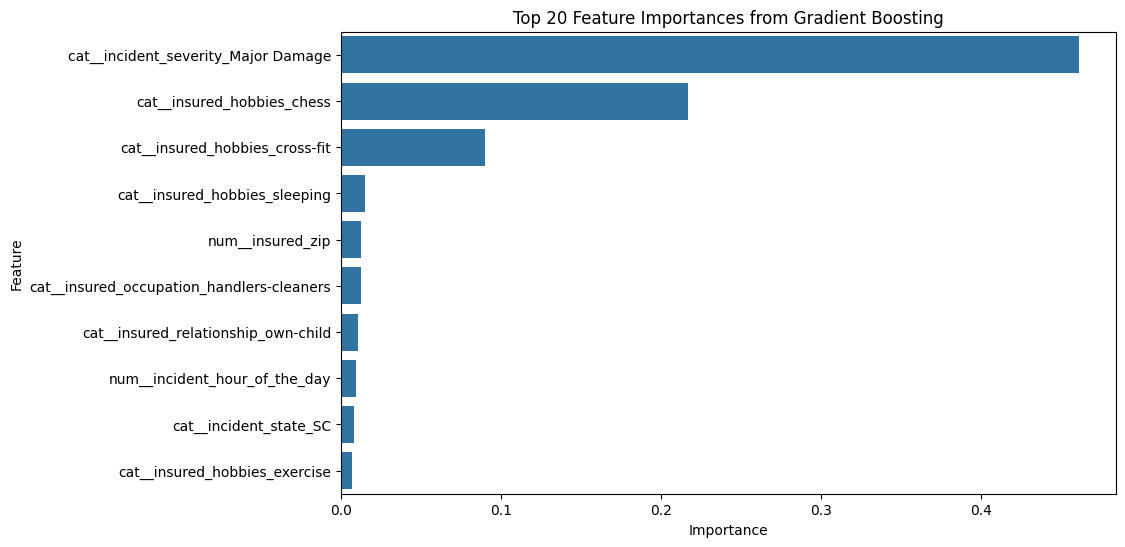

In [ ]:
# Feature Importance for Gradient Boosting top 10 features
feature_importances = best_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 20 Feature Importances from Gradient Boosting")
plt.show()

In [ ]:
# save the best model
joblib.dump(best_model, "best_insurance_fraud_model.pkl")

['best_insurance_fraud_model.pkl']